<h1 align="center"><font size="5">Deep Learning: Convolutional Neural Networks - Final Assignment</font></h1>


## Data description

Waste management is a big problem around the world. Most of the wastes end up in landfills. This leads to many issues like  
- Increase in landfills
- Eutrophication
- Consumption of toxic waste by animals
- Leachate
- Increase in toxins
- Land, water and air pollution

I will be using the Waste Classification Dataset [dataset](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/o-vs-r-split.tar.gz):

- Dataset has two classes (Organic and recyclable)  
- Dataset is divided into train data (85%) and test data (15%) 

### Objective:

Our goal is to train an algorithm on these files and to predict the labels for images in our test set (1 = recyclable, 0 = organic).

## Import the required libraries


In [1]:
import numpy as np
import glob

import warnings
warnings.simplefilter('ignore')

from matplotlib import pyplot as plt
import seaborn as sns

from random import seed
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils import shuffle
from sklearn import metrics

sns.set_context('notebook')
sns.set_style('white')


## Importing the Dataset


### Loading Images using ImageDataGenerator class

The folder structure looks as follows:
```python
DATASET/
└── train
    ├── O
    └── R
└── test
    ├── O
    └── R
```
O - organic class  
R - recyclable class  


Now we will create ImageDataGenerators used for training, validation, and testing.

Image data generators create batches of tensor image data with real-time data augmentation. They loop over the data in batches and are useful in feeding data to the training process. We specify a 20% validation split.

We will perform a few image augmentation steps:
* The __width_shift_range__ shifts the image horizontally (left or right). 
* The __height_shift_range__ shifts the image vertically (up or down). 
* The __horizontal_flip__ randomly flip inputs horizontally.



In [2]:
val_split = 0.2
data_path = '../data/o-vs-r-split'
path = data_path + '/train/' # path to train data
path_test = data_path + '/test/' # path to test data
labels = ['O', 'R'] # labels for the dataset
batch_size = 32
n_epochs = 10
img_rows, img_cols = 150, 150
seed = 10
n_epochs = 10
n_classes = 2
verbosity = 1
checkpoint_path='ORnet.h5'

In [3]:
# Create ImageDataGenerators for training and validation and testing
train_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

The __flow_from_directory__ method takes the ImageDataGenerator training/validation sets and flows image batches from a specified folder, without loading all of our image data into memory all at once. 

In [4]:
# use the labels defined before to 
# find number of images belonging to each category
train_generator = train_datagen.flow_from_directory(
    directory = path,
    classes = labels,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_rows),
    subset = 'training'
)

Found 5810 images belonging to 2 classes.


In [5]:
class_names = {y: x for x, y in train_generator.class_indices.items()}
class_names

{0: 'O', 1: 'R'}

In [6]:
val_generator = val_datagen.flow_from_directory(
    directory = path,
    classes = labels,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_rows),
    subset = 'validation'
)

Found 1452 images belonging to 2 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    directory = path_test,
    classes = labels,
    class_mode='binary',
    seed = seed,
    batch_size = batch_size, 
    shuffle = False,
    target_size=(img_rows, img_rows)
)

Found 828 images belonging to 2 classes.


### Helper functions

In [8]:
# converts predictions to classes
num2class_lt = lambda l: ['O' if x < 0.5 else 'R' for x in l]

# helper function to get images data from a specified path
def getImagesData(subset = 'train'):
    IMG_DIM = (150, 150)

    # list of files
    files_O = glob.glob(f'{data_path}/{subset}/O/*')
    files_R = glob.glob(f'{data_path}/{subset}/R/*')
    files = files_O + files_R
    files = shuffle(files)

    # train images as arrays
    imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in files]
    imgs = np.array(imgs)

    # train labels
    # this may need to be modified based on OS. It is tested on Windows. 
    labels = [fn.split('/')[-1].split('\\')[0].strip() for fn in files]

    return imgs, labels

# helper function to display images from a list of images
def displayImage(imgs, labels, img_id = 0):
    O_generator = train_datagen.flow(imgs[img_id:img_id+1], labels[img_id:img_id+1],
                                    batch_size=1)
    O = [next(O_generator) for i in range(0,5)]

    fig, ax = plt.subplots(1,5, figsize=(16, 16))
    print('Labels:', [item[1][0] for item in O])
    l = [ax[i].imshow(O[i][0][0]) for i in range(0,5)]

Labels: ['R', 'R', 'R', 'R', 'R']


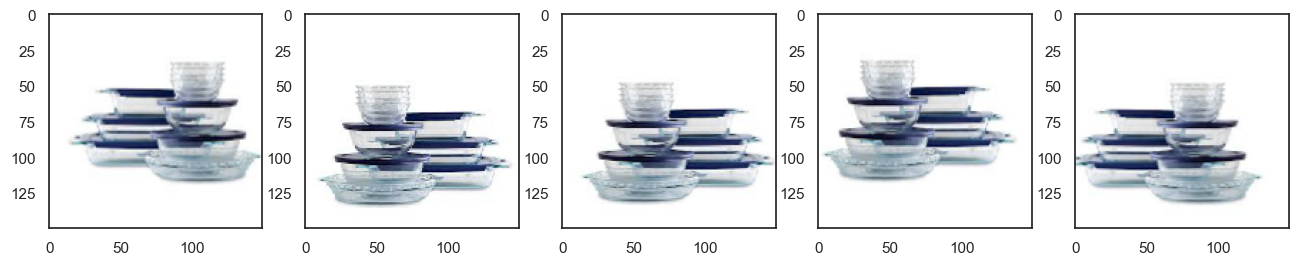

In [9]:
train_imgs, train_labels = getImagesData('train')
displayImage(train_imgs, train_labels, 1)

In [ ]:
# train_imgs_r, train_labels_r = getImagesData('train')
# displayImage(train_imgs_r, train_labels_r, 1)

# CNN


In [10]:
model_cnn = Sequential()

model_cnn.add(Conv2D(32, (5, 5), padding='same', input_shape = (img_rows, img_cols, 3), activation = 'relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
model_cnn.add(Flatten())
model_cnn.add(Dense(units = 256, activation = 'relu'))
model_cnn.add(Dense(units = 1, activation = 'sigmoid'))

In [11]:
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 87616)             0         
                                                                 
 dense (Dense)               (None, 256)               2

In [12]:
model_cnn.compile(optimizer='adam', 
              loss="binary_crossentropy",
              metrics=['accuracy'])

In [13]:
model_cnn_history = model_cnn.fit(
  train_generator,
  validation_data=val_generator,
  epochs=4
)

Epoch 1/4
182/182 [==============================] - 45s 200ms/step - loss: 0.6060 - accuracy: 0.7597 - val_loss: 0.4478 - val_accuracy: 0.7948
Epoch 2/4
182/182 [==============================] - 34s 188ms/step - loss: 0.4488 - accuracy: 0.8102 - val_loss: 0.4560 - val_accuracy: 0.7851
Epoch 3/4
182/182 [==============================] - 90s 494ms/step - loss: 0.4298 - accuracy: 0.8157 - val_loss: 0.4134 - val_accuracy: 0.8072
Epoch 4/4
182/182 [==============================] - 108s 593ms/step - loss: 0.4000 - accuracy: 0.8337 - val_loss: 0.4111 - val_accuracy: 0.8182


In [14]:
test_predictions = model_cnn.predict(test_generator)

26/26 [==============================] - 2s 78ms/step


In [15]:
test_predictions_class = num2class_lt(test_predictions)
test_target_classes = num2class_lt(test_generator.classes)

print('CNN classification report')
print(metrics.classification_report(test_target_classes, test_predictions_class))

CNN classification report
              precision    recall  f1-score   support

           O       0.85      0.83      0.84       465
           R       0.79      0.82      0.80       363

    accuracy                           0.82       828
   macro avg       0.82      0.82      0.82       828
weighted avg       0.82      0.82      0.82       828



# VGG-16

In [ ]:
input_shape = (150, 150, 3)

vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)

In [ ]:
output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

In [ ]:
basemodel.trainable = False
for layer in basemodel.layers: layer.trainable = False

In [ ]:
input_shape = basemodel.output_shape[1]

model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu', input_dim=input_shape))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
print(model.summary())

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=2e-5),
              metrics=['accuracy'])

In [ ]:
keras_callbacks = [
      EarlyStopping(monitor = 'loss', 
                    patience = 5, 
                    mode = 'min', 
                    min_delta=0.01),
      ModelCheckpoint('O_R_tlearn_image_augm_cnn_vgg16.h5', monitor='loss', save_best_only=True, mode='min')
]

In [ ]:
vgg16_model = model.fit(train_generator, 
                              steps_per_epoch=10, 
                              epochs=5,
                              validation_data=val_generator, 
                              validation_steps=10, 
                              verbose=1,
                              callbacks = [keras_callbacks])  

# 4. Insights and key findings


# 5. Next Steps


## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
